# Prédiction des charges d’assurance – Analyse exploratoire (EDA)

## Contexte
Un assureur souhaite anticiper les charges médicales à partir de variables
démographiques et de santé afin d’améliorer la tarification et la gestion du risque.

## Objectifs de ce notebook
- Comprendre la structure et la qualité des données
- Identifier les variables influençant les charges
- Mettre en évidence des insights métier
- Préparer les choix de modélisation pour la semaine 2


### Dictionnaire des Variables

| Variable | Type | Rôle | Description |
| :--- | :--- | :--- | :--- |
| **age** | Numérique | Feature | Âge de l'assuré (18-64 ans) |
| **sex** | Catégorielle | Feature | Sexe (male/female) |
| **bmi** | Numérique | Feature | Indice de Masse Corporelle (IMC) |
| **children** | Numérique | Feature | Nombre d'enfants à charge |
| **smoker** | Catégorielle | Feature | Fumeur (yes/no) |
| **region** | Catégorielle | Feature | Région aux USA (4 zones) |
| **charges** | Numérique | **Cible** | Frais médicaux annuels |

In [244]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import plotly.express as px


# 1. Chargement des données (Chemin pour dossier /notebooks)
path = '../data/insurance.csv'

if os.path.exists(path):
    # Création d'un dictionnaire pour forcer le typage (Par défaut Pandas attribue toujours le type de données à la mémoire la plus élevée)
    df_without_optimized = pd.read_csv(path, low_memory=True)
    dtype_dict = {'age': 'int8', 'sex': 'category', 'bmi': 'float64', 'children': 'int8', 'smoker': 'category', 'region': 'category', 'charges': 'float32'}

    df = pd.read_csv(path, low_memory=True, dtype=dtype_dict)
    df["smoker"] = df["smoker"].map({"yes": 1, "no": 0}).astype("bool")

    print("Avant optimisation :")
    print("Utilisation mémoire par colonne :")
    print(f"  Niveau : {df_without_optimized.memory_usage(deep=True)} bytes")

    print(f"\nTotal : {df_without_optimized.memory_usage(deep=True).sum() / 1024:.2f} KB")
    print("\nAprès optimisation :")
    print("Utilisation mémoire par colonne :")
    print(f"  Niveau : {df.memory_usage(deep=True)} bytes")

    print("Utilisation mémoire par colonne :")
    
    print(f"\nTotal : {df.memory_usage(deep=True).sum() / 1024:.2f} KB")
    print(" Les données sont prêtes pour l'analyse de la Semaine 1.")
    lines, cols = df.shape
    print(f"Dataset : {lines} lignes et {cols} colonnes.")
    df["smoker_label"] = df["smoker"].map({True: "Smoker", False: "No-smoker"})
else:
    print(f" Erreur : Je ne trouve pas le fichier au chemin : {path}")
    print("Vérifie bien que ton notebook est dans  le dossier 'notebooks'.")


df.isna().sum()

Avant optimisation :
Utilisation mémoire par colonne :
  Niveau : Index         132
age         10704
sex         72238
bmi         10704
children    10704
smoker      68512
region      77604
charges     10704
dtype: int64 bytes

Total : 255.18 KB

Après optimisation :
Utilisation mémoire par colonne :
  Niveau : Index        132
age         1338
sex         1446
bmi         2676
children    1338
smoker      1338
region      1742
charges     5352
dtype: int64 bytes
Utilisation mémoire par colonne :

Total : 15.00 KB
 Les données sont prêtes pour l'analyse de la Semaine 1.
Dataset : 1338 lignes et 7 colonnes.


age             0
sex             0
bmi             0
children        0
smoker          0
region          0
charges         0
smoker_label    0
dtype: int64

In [245]:
# Fixation de la graine aléatoire pour la reproductibilité
import numpy as np
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
print(f"Graine aléatoire fixée à : {RANDOM_SEED}")

Graine aléatoire fixée à : 42


In [246]:
# 3 Informations sur le DataFrame
# contrôle des doublons
number_duplicated = df.duplicated().sum()
print(f"Il y a {number_duplicated} doublon")
# Visualiser le doublon
print(df[df.duplicated()])

# Voir toutes les lignes concernées
print(df[df.duplicated(keep=False)])
# Vérifier doublons sur les colonnes clés
df.duplicated(subset=["age","sex","bmi","children","smoker","region"]).sum()

df[df.duplicated(keep=False)]

# les lignes concerné sont strictement identique, nous avons donc choisi de le supprimer
# Suppression des doublons
df = df.drop_duplicates()

# Vérification après suppression
print(df.duplicated().sum())


# Vérification de valeur null
print(df.isnull().sum())

print("Aucune valeur null")



Il y a 1 doublon
     age   sex   bmi  children  smoker     region  charges smoker_label
581   19  male 30.59         0   False  northwest 1,639.56    No-smoker
     age   sex   bmi  children  smoker     region  charges smoker_label
195   19  male 30.59         0   False  northwest 1,639.56    No-smoker
581   19  male 30.59         0   False  northwest 1,639.56    No-smoker
0
age             0
sex             0
bmi             0
children        0
smoker          0
region          0
charges         0
smoker_label    0
dtype: int64
Aucune valeur null


In [247]:
# Statistiques de base : mean, median, std, min, max, quartiles
df.describe()

,age,bmi,children,charges
count,"1,337.00","1,337.00","1,337.00","1,337.00"
mean,39.22,30.66,1.10,"13,279.12"
std,14.04,6.10,1.21,"12,110.36"
min,18.00,15.96,0.00,"1,121.87"
25%,27.00,26.30,0.00,"4,746.34"
50%,39.00,30.41,1.00,"9,386.16"
75%,51.00,34.69,2.00,"16,657.72"
max,64.00,53.12,5.00,"63,770.43"


In [248]:
# Nombre de valeurs uniques par colonne
df.nunique()



age               47
sex                2
bmi              486
children           6
smoker             2
region             4
charges         1337
smoker_label       2
dtype: int64

# 2. Analyse Univariée (Distributions)

Analyse de chaque variable indépendamment pour comprendre leur répartition et détecter d'éventuels problèmes (skewness, outliers).

## 2.1 Variables numériques

### Les charges

In [249]:
print(df["charges"].describe())

count    1,337.00
mean    13,279.12
std     12,110.36
min      1,121.87
25%      4,746.34
50%      9,386.16
75%     16,657.72
max     63,770.43
Name: charges, dtype: float64


In [250]:
f"{df.charges.sum():,.0f}"


'17,754,186'

In [251]:
df["charges"].skew()

np.float32(1.5153909)

In [252]:

fig = px.histogram(
    df,
    x="charges",
    nbins=50,
    opacity=0.75,
    title="Distribution des charges d'assurance"
)

fig.update_layout(
    xaxis_title="Charges",
    yaxis_title="Assurés",
    bargap=0.1
)

fig.show()

In [253]:
fig = px.box(
    df,
    x=df["charges"],
   
    title="Distribution des charges d'assurance",
    labels={
        "charges": "Charges d’assurance"
    }
)

fig.show()


La distribution des charges est fortement asymétrique à droite.
La majorité des observations se concentre sur des montants relativement faibles,
tandis qu’un nombre limité d’assurés présente des charges très élevées.

La moyenne est nettement supérieure à la médiane, ce qui confirme
l’influence importante des valeurs extrêmes sur la distribution.

Le boxplot met en évidence de nombreux outliers supérieurs,
et l’écart interquartile élevé traduit une forte dispersion des coûts.

D’un point de vue métier, cette distribution reflète un phénomène classique
en assurance santé : une minorité d’assurés concentre une part significative
des dépenses médicales.

Ces profils à coûts élevés représentent un risque financier majeur
pour l’assureur et justifient une attention particulière dans
les modèles de tarification et de gestion du risque.

Le coefficient d’asymétrie est élevé, confirmant une distribution
fortement déséquilibrée vers les charges élevées.




In [254]:
q1 = df["charges"].quantile(0.25)
q3 = df["charges"].quantile(0.75)
iqr = q3 - q1

q1, q3, iqr

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

q1, q3, iqr, lower_bound, upper_bound


(np.float32(4746.344),
 np.float32(16657.717),
 np.float32(11911.373),
 np.float32(-13120.715),
 np.float32(34524.773))

In [255]:
outliers = df[(df["charges"] < lower_bound) | (df["charges"] > upper_bound)]
print(outliers)

      age     sex   bmi  children  smoker     region   charges smoker_label
14     27    male 42.12         0    True  southeast 39,611.76       Smoker
19     30    male 35.31         0    True  southwest 36,837.47       Smoker
23     34  female 31.92         1    True  northeast 37,701.88       Smoker
29     31    male 36.31         2    True  southwest 38,711.00       Smoker
30     22    male 35.59         0    True  southwest 35,585.57       Smoker
...   ...     ...   ...       ...     ...        ...       ...          ...
1300   45    male 30.36         0    True  southeast 62,592.88       Smoker
1301   62    male 30.88         3    True  northwest 46,718.16       Smoker
1303   43    male 27.80         0    True  southwest 37,829.72       Smoker
1313   19  female 34.69         2    True  southwest 36,397.57       Smoker
1323   42  female 40.38         2    True  southeast 43,896.38       Smoker

[139 rows x 8 columns]


### Les Ages

In [256]:
df["age"].describe()

count   1,337.00
mean       39.22
std        14.04
min        18.00
25%        27.00
50%        39.00
75%        51.00
max        64.00
Name: age, dtype: float64

In [257]:
df["age"].skew()

np.float64(0.054780773126998195)

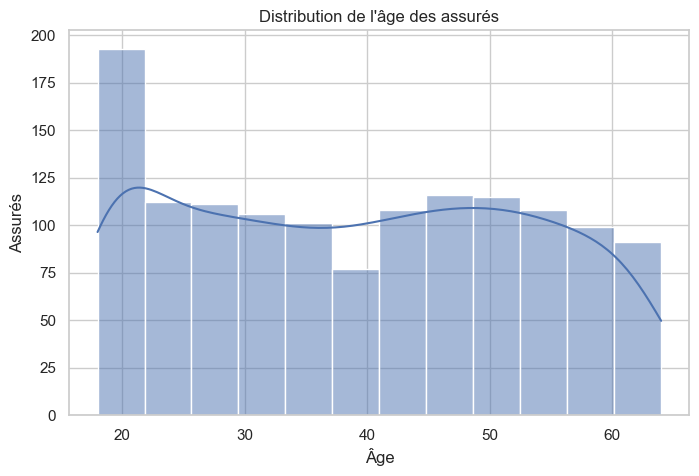

In [258]:
plt.figure(figsize=(8,5))
sns.histplot(df["age"], kde=True)
plt.title("Distribution de l'âge des assurés")
plt.xlabel("Âge")
plt.ylabel("Assurés")
plt.show()


In [288]:
bins_age = [18, 30, 40, 50, 60, 100]
labels_age = [
    "18-29",
    "30-39",
    "40-49",
    "50-59",
    "60+"
]

df["age_group"] = pd.cut(
    df["age"],
    bins=bins_age,
    labels=labels_age,
    right=False
)

fig = px.box(
    df,
    x="age_group",
   
    title="Distribution des charges par classe d’âge",
    labels={
        "age_group": "Classe d’âge",
        "charges": "Charges d’assurance"
    }
)

fig.show()

fig2 = px.histogram(
    df,
    x="age_group",
    y="charges",
    nbins=50,
    opacity=0.75,
    title="Distribution des charges d'assurance",
    category_orders={
        "age_group": ["18-29", "30-39", "40-49", "50-59", "60+"]
    }
)

fig2.show()





In [260]:
fig = px.box(
    df,
    x=df["age"],
   
    title="Distribution des âges",
    labels={
        "age": "Âges"
    }
)

fig.show()


La distribution de l’âge est relativement uniforme sur l’intervalle observé,
avec une légère concentration autour des âges moyens.
La moyenne et la médiane sont proches, indiquant une distribution
globalement symétrique, sans asymétrie marquée.

Le boxplot ne met pas en évidence de valeurs extrêmes significatives.


D’un point de vue métier, la population assurée couvre un large éventail d’âges,
ce qui permet au modèle d’apprendre des profils de risque variés.
L’âge est un facteur naturellement lié à la consommation de soins
et constitue une variable explicative pertinente pour la prédiction des charges.


La variable `age` ne nécessite pas de traitement particulier concernant
les valeurs extrêmes. Une standardisation pourra néanmoins être appliquée
afin d’assurer une mise à l’échelle cohérente avec les autres variables numériques.


### Le BMI

In [261]:
df["bmi"].describe()

count   1,337.00
mean       30.66
std         6.10
min        15.96
25%        26.30
50%        30.41
75%        34.69
max        53.12
Name: bmi, dtype: float64

In [262]:
df["bmi"].skew()

np.float16(0.2837)

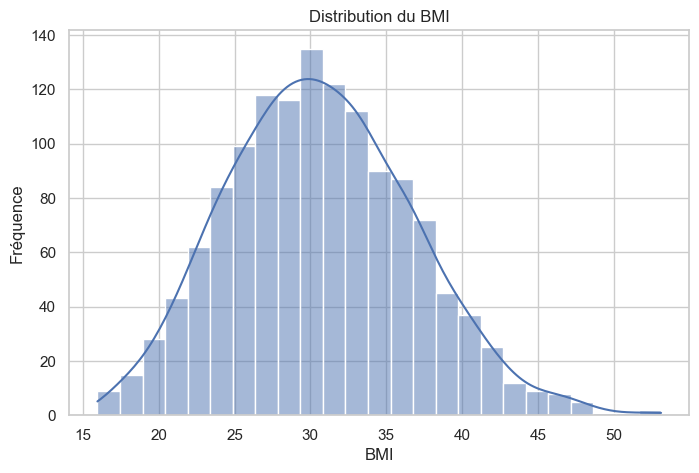

In [263]:
plt.figure(figsize=(8,5))
sns.histplot(df["bmi"], kde=True)
plt.title("Distribution du BMI")
plt.xlabel("BMI")
plt.ylabel("Fréquence")
plt.show()

In [264]:
bins_bmi = [0, 18.5, 25, 30, 100]
labels_bmi = ["Underweight", "Normal", "Overweight", "Obese"]


df["bmi_category"] = pd.cut(
    df["bmi"],
    bins=bins_bmi,
    labels=labels_bmi,
    right=False
)

fig = px.box(
    df,
    x="bmi_category",
   
    title="Distribution des bmi",
    labels= {
        "bmi_category": "Category of BMI"
    }
)

fig.show()


fig2 = px.box(
    df,
    x=df["bmi"],
   
    title="Distribution des bmi",
    labels={
        "charges": "bmi"
    }
)

fig2.show()


La distribution du BMI est légèrement asymétrique à droite,
avec une concentration autour des valeurs correspondant
au surpoids et à l’obésité légère.

Quelques valeurs extrêmes sont observées, mais elles restent
cohérentes d’un point de vue médical.


D’un point de vue métier, un BMI élevé est généralement associé
à un risque accru de pathologies chroniques, entraînant
des coûts médicaux plus importants.

La présence de BMI élevés dans la population étudiée
suggère un levier de segmentation pertinent pour l’assureur.


La variable `bmi` pourra être conservée telle quelle,
avec une standardisation. Une interaction avec d’autres variables
(comme le tabagisme ou l’âge) pourra être explorée ultérieurement.

### les Enfants

In [265]:
df["children"].describe()

count   1,337.00
mean        1.10
std         1.21
min         0.00
25%         0.00
50%         1.00
75%         2.00
max         5.00
Name: children, dtype: float64

In [266]:
print(df["children"].skew())

0.9374206440474123


In [267]:
children_counts = (
    df.groupby("children", observed=True)
      .size()
      .reset_index(name="count")
)

px.bar(
    children_counts,
    x="children",
    y="count",
    title="Répartition des assurés par sexe"
).show()

In [268]:
fig = px.box(
    df,
    x=df["children"],
   
    title="Distribution des enfants",
    labels={
        "charges": "Nombres d'enfants"
    }
)

fig.show()


La distribution du nombre d’enfants est discrète et fortement concentrée
sur les valeurs faibles (0, 1 ou 2 enfants).
La majorité des assurés n’a pas ou peu d’enfants à charge.

La variable présente une asymétrie à droite,
avec très peu d’observations pour les valeurs élevées.


D’un point de vue métier, le nombre d’enfants à charge peut influencer
les charges globales d’un foyer, mais son impact individuel
sur les coûts médicaux reste potentiellement limité.

Cette variable pourrait néanmoins jouer un rôle secondaire
dans la prédiction des charges.


La variable `children`, bien que numérique, est discrète.
Elle pourra être utilisée telle quelle dans un modèle linéaire,
sans transformation particulière.


## 2.2 Variables catégorielles

### le Sex

In [269]:
df["sex"].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [270]:
df["sex"].value_counts(normalize=True) * 100

sex
male     50.49
female   49.51
Name: proportion, dtype: float64

In [271]:
sex_counts = (
    df.groupby("sex", observed=True)
      .size()
      .reset_index(name="count")
)


px.bar(
    sex_counts,
    x="sex",
    y="count",
    title="Répartition des assurés par sexe"
).show()



La population assurée est relativement équilibrée entre hommes et femmes,
avec une légère majorité d’hommes.
Aucun déséquilibre majeur n’est observé entre les deux modalités.


D’un point de vue métier, cette répartition équilibrée permet
d’évaluer l’impact du sexe sur les charges sans biais lié
à une surreprésentation d’une catégorie.


La variable `sex` pourra être intégrée au modèle via un encodage
binaire (One-Hot Encoding).


### Fumeurs ou non

In [272]:
df["smoker"].value_counts()

smoker
False    1063
True      274
Name: count, dtype: int64

In [273]:
df["smoker"].value_counts(normalize=True) * 100

smoker
False   79.51
True    20.49
Name: proportion, dtype: float64

In [274]:
smoker_counts = (
    df.groupby("smoker_label", observed=True)
      .size()
      .reset_index(name="count")
)

px.bar(
    smoker_counts,
    x="smoker_label",
    y="count",
    title="Répartition des assurés selon le statut fumeur"
).show()

La majorité des assurés sont non-fumeurs, tandis que les fumeurs
représentent une minorité de la population étudiée.


D’un point de vue métier, bien que les fumeurs soient minoritaires,
ils sont généralement associés à un risque médical plus élevé,
ce qui laisse présager un impact significatif sur les charges d’assurance.


La variable `smoker` est susceptible d’être un facteur explicatif majeur.
Elle sera encodée et analysée avec attention lors de la modélisation.


### Les Regions

In [275]:
df["region"].value_counts()

region
southeast    364
southwest    325
northeast    324
northwest    324
Name: count, dtype: int64

In [276]:
df["region"].value_counts(normalize=True) * 100

region
southeast   27.23
southwest   24.31
northeast   24.23
northwest   24.23
Name: proportion, dtype: float64

In [277]:
region_counts = (
    df.groupby("region", observed=True)
      .size()
      .reset_index(name="count")
)

px.bar(
    region_counts,
    x="region",
    y="count",
    title="Répartition des assurés par région"
).show()


La population assurée est relativement bien répartie entre les différentes régions,
sans déséquilibre majeur entre les modalités.


D’un point de vue métier, l’absence de déséquilibre régional suggère
que la variable `region` ne reflète pas une segmentation forte
des profils de risque à ce stade de l’analyse.


La variable `region` pourra être intégrée via un encodage One-Hot.
Son impact réel sera évalué lors de la phase de modélisation.


# 3 Analyse bivariée

## 3.1 Variables catégorielles

### Smoker vs charges

Objectif :
Comparer les charges d’assurance entre fumeurs et non-fumeurs
afin d’évaluer l’impact du tabagisme sur les coûts médicaux.


In [278]:
df.groupby("smoker_label")["charges"].describe()

,count,mean,std,min,25%,50%,75%,max
smoker_label,,,,,,,,
No-smoker,"1,063.00","8,440.66","5,992.97","1,121.87","3,988.88","7,345.73","11,363.02","36,910.61"
Smoker,274.00,"32,050.23","11,541.55","12,829.46","20,826.24","34,456.35","41,019.21","63,770.43"


In [279]:
fig = px.box(
    df,
    x="smoker_label",
    y="charges",
    title="Boxplot d'assurance selon le statut fumeur",
    labels={
        "charges": "smoker_label"
    }
)

fig.show()


Les fumeurs présentent des charges nettement plus élevées que les non-fumeurs,
avec une médiane et une moyenne largement supérieures.

La dispersion des charges est également beaucoup plus importante
chez les fumeurs, indiquant une variabilité accrue des coûts.


D’un point de vue métier, le tabagisme apparaît comme le principal
facteur de risque identifié dans le dataset.

Bien que les fumeurs soient minoritaires, ils génèrent des coûts
médicaux significativement plus élevés, ce qui justifie une
segmentation tarifaire spécifique.


La variable `smoker` sera un facteur explicatif clé du modèle.
Des interactions avec l’âge ou le BMI pourront être explorées
lors des phases ultérieures.


### Sex vs charges

Objectif :
Comparer les charges d’assurance entre hommes et femmes
afin d’identifier d’éventuelles différences de coûts.


In [280]:
df.groupby("sex", observed=True)["charges"].describe()


,count,mean,std,min,25%,50%,75%,max
sex,,,,,,,,
female,662.00,"12,569.58","11,128.70","1,607.51","4,885.16","9,412.96","14,454.69","63,770.43"
male,675.00,"13,975.00","12,971.96","1,121.87","4,654.02","9,377.90","19,006.69","62,592.88"


In [281]:
fig = px.box(
    df,
    x="sex",
    y="charges",
    title="Boxplot des charges d'assurance selon le sexe",
    labels={
        "charges": "Charges",
        "sex": "Sexe"
    }
)

fig.show()

Les distributions des charges entre hommes et femmes sont proches.
Les médianes sont similaires et les écarts observés restent modérés
comparativement à d’autres variables comme le tabagisme.

D’un point de vue métier, le sexe ne semble pas être un facteur
discriminant majeur des charges dans ce dataset.

Son impact potentiel devra néanmoins être évalué dans le modèle final.


La variable `sex` pourra être intégrée au modèle,
mais son poids explicatif est attendu comme secondaire.


### region vs charges

Objectif :
Comparer les charges d’assurance entre les différentes régions
afin d’identifier d’éventuelles disparités géographiques.


In [282]:
df.groupby("region", observed=True)["charges"].describe()


,count,mean,std,min,25%,50%,75%,max
region,,,,,,,,
northeast,324.00,"13,406.38","11,255.80","1,694.80","5,194.32","10,057.65","16,687.36","58,571.07"
northwest,324.00,"12,450.84","11,073.13","1,621.34","4,733.64","8,976.98","14,788.75","60,021.40"
southeast,364.00,"14,735.41","13,971.10","1,121.87","4,440.89","9,294.13","19,526.29","63,770.43"
southwest,325.00,"12,346.94","11,557.18","1,241.56","4,751.07","8,798.59","13,462.52","52,590.83"


In [283]:
fig = px.box(
    df,
    x="region",
    y="charges",
    title="Boxplot des charges d'assurance selon la région",
    labels={
        "charges": "Charges",
        "region": "Region"
    }
)

fig.show()

In [284]:
pd.crosstab(df["region"], df["smoker_label"], normalize="index") * 100

smoker_label,No-smoker,Smoker
region,,
northeast,79.32,20.68
northwest,82.10,17.90
southeast,75.00,25.00
southwest,82.15,17.85


In [285]:
ct = pd.crosstab(df["region"], df["smoker_label"], normalize="index")

ct_long = ct.reset_index().melt(
    id_vars="region",
    value_vars=ct.columns,
    var_name="Statut fumeur",
    value_name="Proportion"
)


fig = px.bar(
    ct_long,
    x="region",
    y="Proportion",
    color="Statut fumeur",
    title="Répartition des fumeurs par région",
    labels={
        "region": "Région",
        "Proportion": "Proportion"
    }
)

fig.update_layout(
    barmode="stack",
    yaxis_tickformat=".0%",
)

fig.show()

Les distributions des charges sont relativement similaires
entre les différentes régions.

Quelques variations sont observées, mais elles restent limitées
et sans tendance marquée.


D’un point de vue métier, la région ne semble pas constituer
un facteur de segmentation fort des charges d’assurance
dans ce dataset.


Ces résultats orienteront les choix de modélisation,
en accordant une attention particulière à la variable `smoker`
et à ses interactions potentielles avec d’autres facteurs de risque.


## 3.2 Variables numériques

### Age vs charges

Objectif :
Analyser la relation entre l’âge des assurés et les charges d’assurance
afin d’évaluer l’évolution des coûts médicaux au cours de la vie.


In [286]:
df[["age", "charges"]].corr()


,age,charges
age,1.00,0.30
charges,0.30,1.00


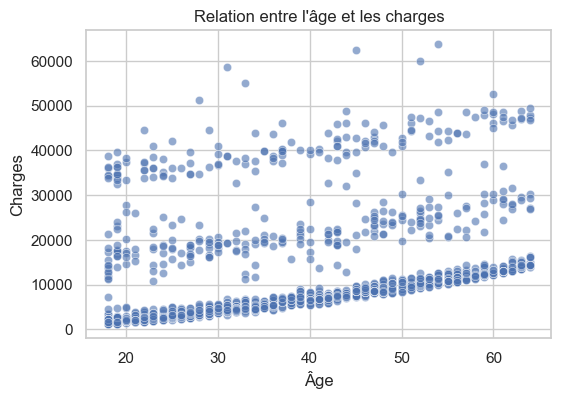

ModuleNotFoundError: No module named 'statsmodels'

In [287]:
# sans droite de régression
plt.figure(figsize=(6,4))
sns.scatterplot(x="age", y="charges", data=df, alpha=0.6)
plt.title("Relation entre l'âge et les charges")
plt.xlabel("Âge")
plt.ylabel("Charges")
plt.show()

fig = px.scatter(
    df,
    x="age",
    y="charges",
    opacity=0.6,
    title="Relation entre l'âge et les charges",
    labels={
        "age": "Âge",
        "charges": "Charges"
    },
    trendline="ols"   # ajoute une droite de régression
)

fig.show()

On observe une relation globalement croissante entre l’âge et les charges :
les coûts médicaux tendent à augmenter avec l’âge.

La corrélation est positive mais modérée, indiquant que l’âge
explique une partie de la variabilité des charges,
sans être le seul facteur déterminant.


D’un point de vue métier, cette relation est cohérente avec
l’augmentation des besoins médicaux au fil du vieillissement.

L’âge constitue donc un facteur de risque naturel
dans la tarification des contrats d’assurance.


La relation relativement linéaire entre l’âge et les charges
rend cette variable compatible avec un modèle de régression linéaire.


### Bmi vs Charges

Objectif :
Analyser l’impact de l’indice de masse corporelle (BMI)
sur les charges d’assurance afin d’évaluer le lien
entre état de santé et coûts médicaux.


In [ ]:
df[["bmi", "charges"]].corr()


In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="bmi", y="charges", data=df, alpha=0.6)
plt.title("Relation entre le BMI et les charges")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

fig = px.scatter(
    df,
    x="bmi",
    y="charges",
    opacity=0.6,
    title="Relation entre le BMI et les charges",
    labels={
        "bmi": "BMI",
        "charges": "Charges"
    },
    trendline="ols"   # ajoute une droite de régression (optionnel mais très utile)
)

fig.show()

La relation entre le BMI et les charges est positive mais dispersée.
Les charges tendent à augmenter pour des valeurs élevées de BMI,
mais avec une forte variabilité.

Cette dispersion suggère que le BMI seul ne suffit pas
à expliquer les charges, et que son effet dépend probablement
d’autres facteurs.


D’un point de vue métier, un BMI élevé est associé
à un risque accru de pathologies chroniques,
mais son impact financier dépend également
du profil global de l’assuré.


La variable `bmi` pourra être intégrée au modèle,
et des interactions avec le tabagisme ou l’âge
pourront être explorées afin de mieux capter son effet.


### Children vs charges

Objectif :
Analyser la relation entre le nombre d’enfants à charge
et les charges d’assurance afin d’évaluer son influence
sur les coûts médicaux.


In [ ]:
df.groupby("children")["charges"].mean()


In [ ]:
df.groupby("children")["charges"].describe()

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x="children", y="charges", data=df)
plt.title("Charges selon le nombre d'enfants")
plt.xlabel("Nombre d'enfants")
plt.ylabel("Charges")
plt.show()

fig = px.box(
    df,
    x="children",
    y="charges",
    title="Boxplot des charges selon le nombre d'enfants",
    labels={
        "charges": "Charges",
        "children": "Children"
    }
)

fig.show()

Les charges moyennes ne varient pas de manière monotone
avec le nombre d’enfants.

Aucune relation claire ou linéaire ne se dégage,
suggérant un impact limité de cette variable
sur les charges individuelles.


D’un point de vue métier, le nombre d’enfants à charge
n’est pas directement lié aux coûts médicaux individuels,
mais peut refléter des caractéristiques socio-démographiques.


La variable `children` pourra être intégrée au modèle,
mais son pouvoir explicatif est attendu comme faible.


# 4 Analyse des corrélations globales

Objectif :
Analyser les relations linéaires entre les variables numériques
afin d’identifier les facteurs les plus corrélés aux charges
et d’anticiper les choix de modélisation.


In [ ]:
# Heatmap : Corrélation entre variables continues
# Visualise les corrélations entre âge, BMI, nombre d'enfants et charges.(ici nous prenons que les valeurs numériques)

df_num = df.select_dtypes(include="number")
df_num.columns

corr_matrix = df_num.corr()
corr_matrix

plt.figure(figsize=(8,6))
sns.heatmap(
    df[["age", "bmi", "children", "smoker", "charges"]].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Matrice de corrélation des variables numériques")
plt.show()


En intégrant la variable `smoker`, encodée sous forme binaire (0 = non-fumeur, 1 = fumeur),
la matrice de corrélation met en évidence que le tabagisme est la variable
la plus fortement corrélée aux charges d’assurance.

La corrélation positive élevée entre `smoker` et `charges` confirme
les observations issues de l’analyse bivariée :
les assurés fumeurs génèrent en moyenne des coûts nettement plus importants.

Les variables `age` et `bmi` présentent également une corrélation positive
avec les charges, bien que d’intensité plus modérée.
Ces résultats suggèrent que l’augmentation du risque médical
est progressive avec l’âge et le niveau de BMI.

À l’inverse, la variable `children` montre une corrélation faible avec les charges,
indiquant un impact limité dans un cadre de relation linéaire.

Il est important de souligner que la corrélation calculée pour la variable `smoker`
reflète une relation moyenne entre deux groupes distincts
(fumeurs vs non-fumeurs) et ne capture pas la complexité
des interactions possibles avec d’autres variables comme l’âge ou le BMI.

Enfin, comme toute mesure de corrélation, cette analyse se limite
aux relations linéaires et ne permet pas d’inférer une relation causale.


## Analyse multivariée exploratoire (bonus)

### Interaction smoker × age

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x="age",
    y="charges",
    hue="smoker_label",
    data=df,
    alpha=0.6
)
plt.title("Charges selon l'âge et le statut fumeur")
plt.show()

fig = px.scatter(
    df,
    x="age",
    y="charges",
    color="smoker_label",
    opacity=0.6,
    title="Charges selon l'âge et le statut fumeur",
    labels={
        "age": "Age",
        "charges": "Charges"
    },
    trendline="ols"   # ajoute une droite de régression (optionnel mais très utile)
)

fig.show()

L’impact du tabagisme sur les charges est visible
à tous les âges, mais tend à s’amplifier
chez les assurés plus âgés.

Cela suggère une possible interaction
entre l’âge et le tabagisme.


### Interaction smoker × bmi

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x="bmi",
    y="charges",
    hue="smoker_label",
    data=df,
    alpha=0.6
)
plt.title("Charges selon le BMI et le statut fumeur")
plt.show()

fig = px.scatter(
    df,
    x="bmi",
    y="charges",
    color="smoker_label",
    opacity=0.6,
    title="Charges selon le BMI et le statut fumeur",
    labels={
        "bmi": "Bmi",
        "charges": "Charges"
    },
    trendline="ols"
)

fig.show()


Chez les fumeurs, les charges augmentent fortement
avec le BMI, tandis que cette relation est
moins marquée chez les non-fumeurs.

Cette observation suggère un effet combiné
du tabagisme et du surpoids.


In [ ]:
fig = px.scatter(
    df,
    x="bmi",
    y="charges",
    color="smoker_label",
    size="age",
    symbol="sex",
    opacity=0.6,
    title="Impact combiné du BMI, de l'âge, du sex et du tabagisme sur les charges",
    labels={
        "bmi": "BMI",
        "charges": "Charges",
        "smoker": "Fumeur",
        "age": "Âge",
        "sex": "Sexe"
    },
    trendline="ols"
)

fig.show()

Ce graphique montre que les charges d’assurance sont le résultat d’un effet combiné entre l’âge, l’obésité et le tabagisme. Les assurés les plus coûteux sont majoritairement des fumeurs âgés avec un BMI élevé, ce qui justifie une tarification différenciée et l’utilisation simultanée de ces variables dans le modèle prédictif.

## Conclusion semaine 1

INSIGHT 1 — Impact du tabagisme

In [ ]:
df.groupby("smoker_label")["charges"].median()
df.groupby("smoker_label")["charges"].mean()


médiane fumeurs ≈ 34 000

médiane non-fumeurs ≈ 7 000

In [ ]:
print(df.groupby("smoker_label")["charges"].median()["Smoker"] / df.groupby("smoker_label")["charges"].median()["No-smoker"])

INSIGHT 2 — Asymétrie des charges

In [ ]:
print(df["charges"].skew())
df["charges"].describe()

Skewness >> 1 → distribution fortement tirée vers la droite.

In [ ]:
df.groupby("smoker_label")["charges"].std()

Les fumeurs ont un écart-type beaucoup plus élevé → plus de variabilité.

INSIGHT 4 — Moyenne vs Médiane

In [ ]:
moyen = df.groupby("smoker_label")["charges"].mean()
mediane = df.groupby("smoker_label")["charges"].median()
print(f"La moyenne est de {moyen}")
print(f"La mediane est de {mediane}")

La moyenne est largement au-dessus de la médiane → présence d’outliers.

INSIGHT 5 — BMI et charges
Calculs

In [ ]:
df["bmi"].corr(df["charges"])

In [ ]:
df.groupby("smoker")[["bmi","charges"]].corr()

Corrélation positive, plus forte chez les fumeurs.

INSIGHT 6 — Non-fumeurs coûteux

In [ ]:
Q3 = df[df["smoker_label"]=="No-smoker"]["charges"].quantile(0.75)
Q1 = df[df["smoker_label"]=="No-smoker"]["charges"].quantile(0.25)
IQR = Q3 - Q1
upper = Q3 + 1.5*IQR

population = len(df[(df["smoker_label"]=="No-smoker") & (df["charges"]>upper)])
print(f"La population non fumeur mais avec une grande charge médicale est de {population}")
df[(df["smoker_label"]=="No-smoker") & (df["charges"]>upper)]

INSIGHT 7 — Enfants

In [ ]:
print(df["children"].skew())
df.groupby("children")["charges"].mean()


In [ ]:
df["children"].value_counts()


Le nombre d’enfants est positivement lié aux charges jusqu’à 3 enfants, ce qui reflète l’augmentation du nombre de personnes couvertes. Pour les familles très nombreuses (4–5 enfants), les données sont trop rares pour tirer une conclusion fiable.

INSIGHT 8 — Justification du log

In [ ]:
df["charges"].skew() 

In [ ]:
np.log(df["charges"]).skew()

La skewness devient proche de 0.

La transformation logarithmique de la variable cible réduit fortement son asymétrie, rendant la distribution plus proche d’une loi normale, ce qui améliore la stabilité et la performance d’un modèle de régression linéaire.

In [ ]:
from ydata_profiling import ProfileReport

# Génération du rapport automatique (Bonus)
profile = ProfileReport(df, title="Rapport EDA Assurance", explorative=True)
profile.to_file("insurance_eda_report.html")
print("Rapport 'insurance_eda_report.html' généré avec succès.")

